In [1]:
from config import *
from utils_new_20250917 import *

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
#create all df's from the same 100 model runs


# Function to run the model 100 times and collect the results
def run_model_100_times():
    population_results = []
    percentage_population_results = []
    area_results = []
    final_results = []
    
    for _ in range(100):
        coral_model_results = run_coral_model(PSD_T0, MaxYear)
        benthic_cover_results = opts.yearly_benthic_cover_df
        rugosity_results = get_rugosity_list()
        
        # Merge the results into a single DataFrame
        merged_results = pd.merge(coral_model_results, benthic_cover_results, on='Year')
        merged_results['Rugosity'] = rugosity_results
        
        final_results.append(merged_results)
        
        # Collect population, percentage population, and area results
        for year in range(MaxYear + 1):
            population_df = opts.yearly_population_df_list[year]
            surface_area_df = opts.yearly_surface_area_df_list[year]
            
            for mg in ['Branching', 'Foliose', 'Other']:
                # Population Size DataFrame
                pop_size_row = [mg, year] + population_df[mg].tolist()
                population_results.append(pop_size_row)
                
                # Percentage Population Size DataFrame
                total_pop = population_df[mg].sum()
                perc_pop_size_row = [mg, year] + (100 * population_df[mg] / total_pop).tolist()
                percentage_population_results.append(perc_pop_size_row)
                
                # Area DataFrame
                area_row = [mg, year] + surface_area_df[mg].tolist()
                area_results.append(area_row)
    
    # Concatenate all the results into a single DataFrame
    final_df = pd.concat(final_results)
    
    return final_df, population_results, percentage_population_results, area_results

# Run the model 100 times and get the results
final_df, population_results, percentage_population_results, area_results = run_model_100_times()

# Create dataframes for population size, percentage population size, and area
bin_diameters = [i * binSize for i in range(MaxBinId)]
columns = ['MG', 'Year'] + [f'Bin Diameter {d} (cm)' for d in bin_diameters]

population_size_df = pd.DataFrame(population_results, columns=columns)
percentage_population_size_df = pd.DataFrame(percentage_population_results, columns=columns)
area_df = pd.DataFrame(area_results, columns=columns)

# Print the dataframes
print("Final DataFrame")
print(area_df)


Final DataFrame
             MG  Year  Bin Diameter 0 (cm)  Bin Diameter 5 (cm)  \
0     Branching     0             0.007510             0.319191   
1       Foliose     0             0.036615             0.869612   
2         Other     0             4.831636            32.510742   
3     Branching     1             4.246059             0.078540   
4       Foliose     1             4.921501             0.667588   
...         ...   ...                  ...                  ...   
3595    Foliose    10             2.646792            16.846791   
3596      Other    10            94.102481           127.548662   
3597  Branching    11            66.663614           174.692186   
3598    Foliose    11             2.502475            15.275994   
3599      Other    11            92.307846           132.604662   

      Bin Diameter 10 (cm)  Bin Diameter 15 (cm)  Bin Diameter 20 (cm)  \
0                 1.122800              1.915144              2.863704   
1                 2.413992     

In [4]:
#setting seed to ensure repeatability of runs 

final_df, population_results, percentage_population_results, area_results = run_model_iterations_all_parameters(100)

# Create dataframes
bin_diameters = [i * binSize for i in range(MaxBinId)]
columns = ['MG', 'Year'] + [f'Bin Diameter {d} (cm)' for d in bin_diameters]
population_size_df = pd.DataFrame(population_results, columns=columns)
percentage_population_size_df = pd.DataFrame(percentage_population_results, columns=columns)
area_df = pd.DataFrame(area_results, columns=columns)

print("\nArea DataFrame")
print(area_df)




Area DataFrame
             MG  Year  Bin Diameter 0 (cm)  Bin Diameter 5 (cm)  \
0     Branching     0             0.007510             0.319191   
1       Foliose     0             0.036615             0.869612   
2         Other     0             4.831636            32.510742   
3     Branching     1             4.783075             0.078540   
4       Foliose     1             5.068763             0.667588   
...         ...   ...                  ...                  ...   
3595    Foliose    10             3.002184            15.781594   
3596      Other    10           176.888356           175.016163   
3597  Branching    11            60.521801           163.402088   
3598    Foliose    11             3.347760            14.647676   
3599      Other    11           161.083200           189.595117   

      Bin Diameter 10 (cm)  Bin Diameter 15 (cm)  Bin Diameter 20 (cm)  \
0                 1.122800              1.915144              2.863704   
1                 2.413992     

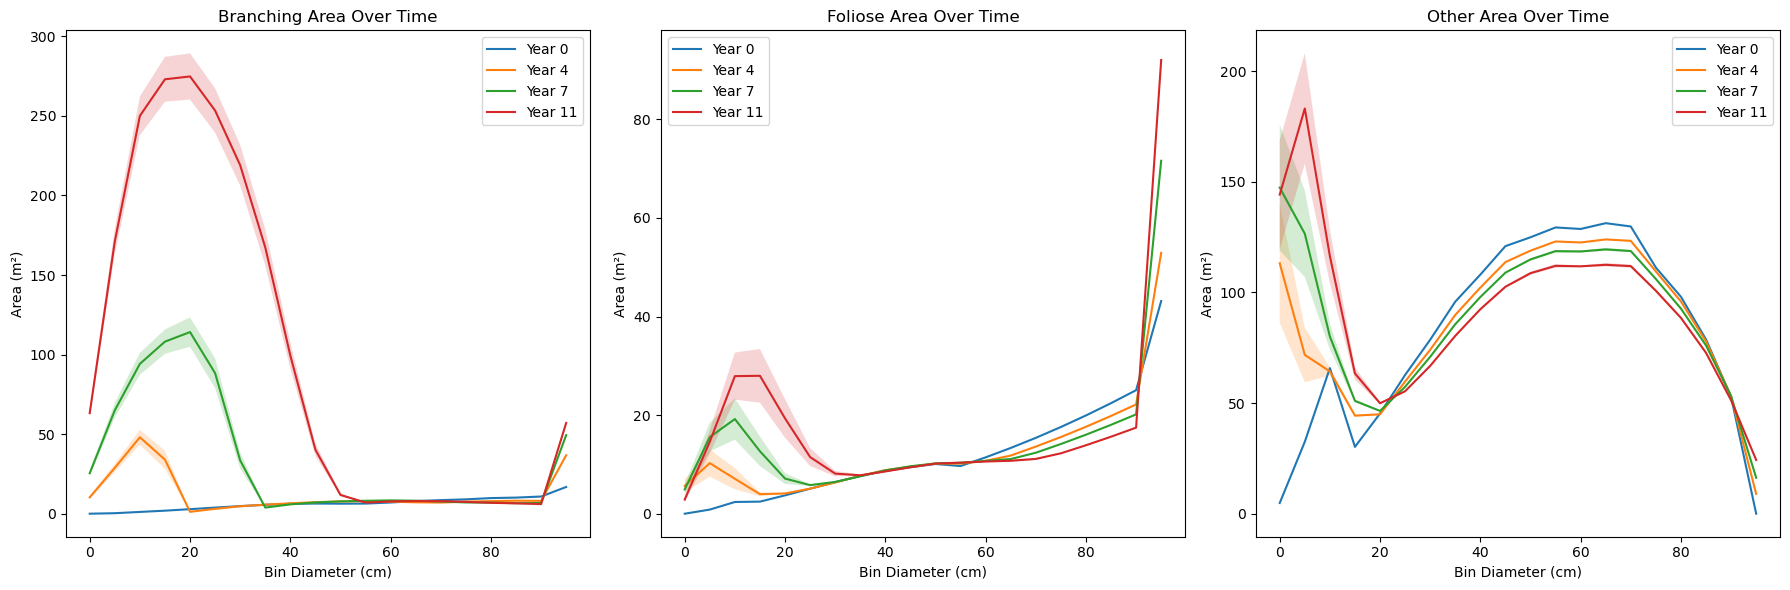

In [5]:
# Function to plot population, percentage population, and area for specific years with standard deviation shades
def plot_graphs_with_std_shades(df, y_label, y_unit):
    bin_diameters = [i * binSize for i in range(MaxBinId)]
    
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    
    for idx, mg in enumerate(['Branching', 'Foliose', 'Other']):
        for year in [0, 4, 7, 11]:
            year_df = df[(df['MG'] == mg) & (df['Year'] == year)]
            mean_values = year_df.iloc[:, 2:].mean()
            std_values = year_df.iloc[:, 2:].std()
            
            axs[idx].plot(bin_diameters, mean_values, label=f'Year {year}')
            axs[idx].fill_between(bin_diameters, mean_values - std_values, mean_values + std_values, alpha=0.2)
        
        axs[idx].set_title(f'{mg} {y_label} Over Time')
        axs[idx].set_xlabel('Bin Diameter (cm)')
        axs[idx].set_ylabel(f'{y_label} {y_unit}')
        axs[idx].legend()
    
    plt.tight_layout()
    plt.show()

# Plot area with standard deviation shades
plot_graphs_with_std_shades(area_df, 'Area', '(m²)')